In [261]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [262]:
data_1 = pd.read_csv("./datasets-location_C/room_climate-location_C-measurement05.csv", header=None)
data_2 = pd.read_csv("./datasets-location_C/room_climate-location_C-measurement06.csv", header=None)

column_names = ["EID", "AbsT", "RelT", "NID", "Temp", "RelH", 
                "L1", "L2", "Occ", "Act", "Door", "Win"]

data_1.columns = column_names
data_2.columns = column_names

In [263]:
print(data_1.columns)
print(data_2.columns)

Index(['EID', 'AbsT', 'RelT', 'NID', 'Temp', 'RelH', 'L1', 'L2', 'Occ', 'Act',
       'Door', 'Win'],
      dtype='object')
Index(['EID', 'AbsT', 'RelT', 'NID', 'Temp', 'RelH', 'L1', 'L2', 'Occ', 'Act',
       'Door', 'Win'],
      dtype='object')


In [264]:
df = pd.concat([data_1, data_2], ignore_index=True)
print(df.columns)

Index(['EID', 'AbsT', 'RelT', 'NID', 'Temp', 'RelH', 'L1', 'L2', 'Occ', 'Act',
       'Door', 'Win'],
      dtype='object')


In [265]:
df.head(5)

,EID,AbsT,RelT,NID,Temp,RelH,L1,L2,Occ,Act,Door,Win
0,1,1485441852008,2,5,21.85,43.020,182.86,542.8,0,0,0,0
1,2,1485441852248,2,4,22.10,38.930,268.57,993.6,0,0,0,0
2,3,1485441852518,3,1,22.12,41.846,148.57,441.6,0,0,0,0
3,4,1485441852603,3,2,22.02,51.485,194.29,538.2,0,0,0,0
4,5,1485441852650,3,3,22.10,36.176,192.86,565.8,0,0,0,0


In [266]:
df.isnull().sum()

EID     0
AbsT    0
RelT    0
NID     0
Temp    0
RelH    0
L1      0
L2      0
Occ     0
Act     0
Door    0
Win     0
dtype: int64

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EID     3000 non-null   int64  
 1   AbsT    3000 non-null   int64  
 2   RelT    3000 non-null   int64  
 3   NID     3000 non-null   int64  
 4   Temp    3000 non-null   float64
 5   RelH    3000 non-null   float64
 6   L1      3000 non-null   float64
 7   L2      3000 non-null   float64
 8   Occ     3000 non-null   int64  
 9   Act     3000 non-null   int64  
 10  Door    3000 non-null   int64  
 11  Win     3000 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 281.4 KB


In [268]:
df = df.drop(columns=['EID', 'AbsT', 'RelT', 'NID', 'Occ', 'Act', 'Door', 'Win'])

# Create next–timestamp label
df["NextTemp"] = df["Temp"].shift(-1)

# Remove last row (because next temperature is NaN)
df = df.dropna()

x = df[["Temp", "RelH", "L1", "L2"]]
y = df["NextTemp"]

In [269]:
df.head(5)

,Temp,RelH,L1,L2,NextTemp
0,21.85,43.020,182.86,542.8,22.10
1,22.10,38.930,268.57,993.6,22.12
2,22.12,41.846,148.57,441.6,22.02
3,22.02,51.485,194.29,538.2,22.10
4,22.10,36.176,192.86,565.8,21.85


In [270]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [271]:
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((4,1), input_shape=(4,)),
    tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu'),
    tf.keras.layers.Conv1D(16, kernel_size=2, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

In [272]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_30"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_28 (Reshape)        (None, 4, 1)              0         
                                                                 
 conv1d_56 (Conv1D)          (None, 3, 32)             96        
                                                                 
 conv1d_57 (Conv1D)          (None, 2, 16)             1040      
                                                                 
 flatten_30 (Flatten)        (None, 32)                0         
                                                                 
 dense_62 (Dense)            (None, 64)                2112      
                                                                 
 dense_63 (Dense)            (None, 1)                 65        
                                                                 
Total params: 3,313
Trainable params: 3,313
Non-train

In [273]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), callbacks=early_stopping)

Epoch 1/100
66/66 [==============================] - 1s 6ms/step - loss: 352.6465 - mae: 18.3189 - val_loss: 51.8903 - val_mae: 6.5966
Epoch 2/100
66/66 [==============================] - 0s 2ms/step - loss: 10.2655 - mae: 2.4283 - val_loss: 3.1562 - val_mae: 1.4119
Epoch 3/100
66/66 [==============================] - 0s 3ms/step - loss: 1.8770 - mae: 1.0653 - val_loss: 1.4884 - val_mae: 0.9495
Epoch 4/100
66/66 [==============================] - 0s 3ms/step - loss: 1.1875 - mae: 0.8359 - val_loss: 1.2341 - val_mae: 0.8304
Epoch 5/100
66/66 [==============================] - 0s 3ms/step - loss: 1.0560 - mae: 0.7741 - val_loss: 1.1527 - val_mae: 0.7938
Epoch 6/100
66/66 [==============================] - 0s 3ms/step - loss: 0.9819 - mae: 0.7377 - val_loss: 1.0809 - val_mae: 0.7714
Epoch 7/100
66/66 [==============================] - 0s 2ms/step - loss: 0.9193 - mae: 0.7086 - val_loss: 1.0267 - val_mae: 0.7617
Epoch 8/100
66/66 [==============================] - 0s 3ms/step - loss: 0.851

In [274]:
loss, mse = model.evaluate(x_test, y_test)
print("Loss: ", loss)

15/15 [==============================] - 0s 1ms/step - loss: 0.0137 - mae: 0.0934
Loss:  0.013655932620167732


In [275]:
y_pred = model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse} | MAE: {mae} | R-squared: {r2}")

15/15 [==============================] - 0s 2ms/step
RMSE: 0.11685863929214664 | MAE: 0.09341503838433173 | R-squared: -0.07533835185920967


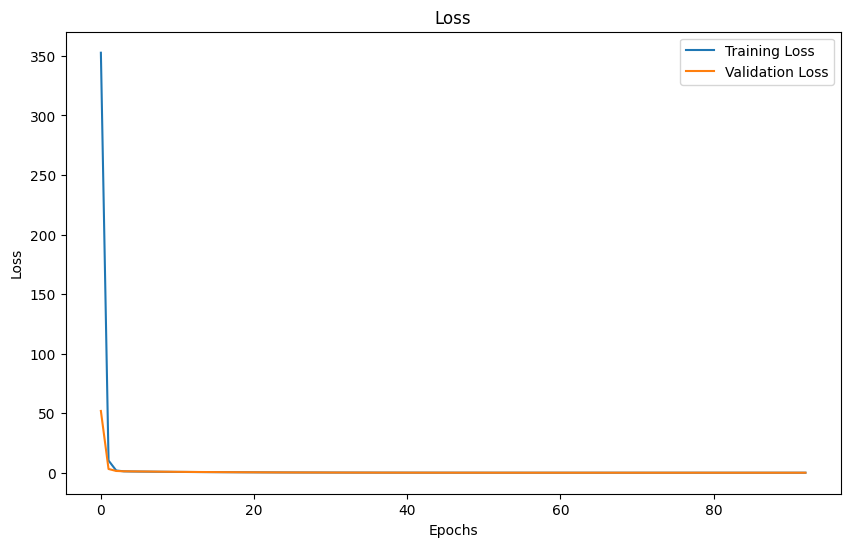

In [276]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

### Analysis
From the training plot, we can see that both the training and validation losses start with very big loss value from the first epoch. The training loss started with around 400, meanwhile validation loss started with about 150. This means that the model initially had very poor predictions.

However, in just a few epochs, both loss curves drop drastically toward zero. This rapid reduction suggests that the model learns the mapping from input features to the next-timestamp temperature very quickly. After the loss curves drop, both the training and validation loss curves flatten and stayed very close to zero until the end of its training.

$RMSE= 0.12$ | $MAE= 0.09$ | $R^2= -0.07$

While the plot shows that the model converges extremely quickly and maintains very low error throughout training, the model training does result in a negative $R^2$, meaning the model is performing worse than simply predicting the mean of the target values. This could indicate overfitting if the model memorized the values instead of learning the actual pattern during training.

## Hyperparameter Tuning

In [ ]:
model_tuned = tf.keras.Sequential([
    tf.keras.layers.Reshape((4,1), input_shape=(4,)),
    tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu'),
    tf.keras.layers.Conv1D(16, kernel_size=2, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'), # Reducing Dense layer size
    tf.keras.layers.Dense(1, activation=None)
])

In [ ]:
# Lower the learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model_tuned.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
model_tuned.summary()

Model: "sequential_51"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_37 (Reshape)        (None, 4, 1)              0         
                                                                 
 conv1d_74 (Conv1D)          (None, 3, 32)             96        
                                                                 
 conv1d_75 (Conv1D)          (None, 2, 16)             1040      
                                                                 
 flatten_39 (Flatten)        (None, 32)                0         
                                                                 
 dense_114 (Dense)           (None, 16)                528       
                                                                 
 dense_115 (Dense)           (None, 1)                 17        
                                                                 
Total params: 1,681
Trainable params: 1,681
Non-train

In [ ]:
# Increase the number of epochs
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_tuned = model_tuned.fit(x_train, y_train, epochs=400, validation_data=(x_val, y_val), callbacks=early_stopping)

Epoch 1/400
66/66 [==============================] - 1s 5ms/step - loss: 489.7126 - mae: 22.1284 - val_loss: 486.4344 - val_mae: 22.0541
Epoch 2/400
66/66 [==============================] - 0s 3ms/step - loss: 482.4493 - mae: 21.9633 - val_loss: 479.0927 - val_mae: 21.8866
Epoch 3/400
66/66 [==============================] - 0s 3ms/step - loss: 474.3953 - mae: 21.7786 - val_loss: 469.8747 - val_mae: 21.6744
Epoch 4/400
66/66 [==============================] - 0s 3ms/step - loss: 463.4290 - mae: 21.5245 - val_loss: 457.0044 - val_mae: 21.3743
Epoch 5/400
66/66 [==============================] - 0s 3ms/step - loss: 447.2598 - mae: 21.1439 - val_loss: 436.6767 - val_mae: 20.8915
Epoch 6/400
66/66 [==============================] - 0s 3ms/step - loss: 421.7298 - mae: 20.5281 - val_loss: 406.2686 - val_mae: 20.1473
Epoch 7/400
66/66 [==============================] - 0s 3ms/step - loss: 387.3326 - mae: 19.6675 - val_loss: 368.1157 - val_mae: 19.1714
Epoch 8/400
66/66 [======================

In [382]:
loss, mse = model_tuned.evaluate(x_test, y_test)
print("Loss: ", loss)

15/15 [==============================] - 0s 2ms/step - loss: 0.0125 - mae: 0.0896
Loss:  0.012476127594709396


In [383]:
y_pred = model_tuned.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse} | MAE: {mae} | R-squared: {r2}")

15/15 [==============================] - 0s 2ms/step
RMSE: 0.11169646636724971 | MAE: 0.0895940505981446 | R-squared: 0.01756833244872269


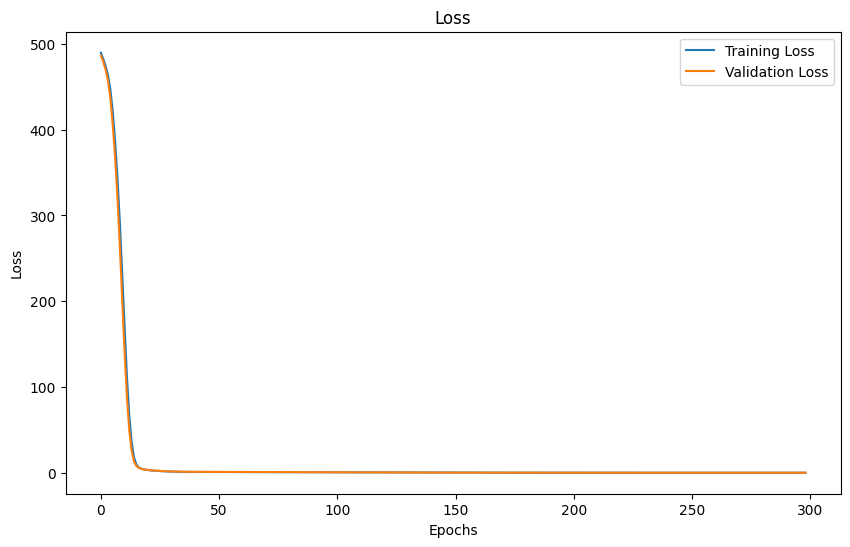

In [384]:
plt.figure(figsize=(10, 6))

plt.plot(history_tuned.history['loss'], label="Training Loss")
plt.plot(history_tuned.history['val_loss'], label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

### Result

$RMSE: 0.11$ | $MAE: 0.09$ | $R^2: 0.018$

The tuned model now results in a positive $R^2$ score, meaning the model now performs slightly better than predicting the mean of the target values.